# Importing a custom Pytorch model into a SageMaker JumpStart private model hub. 


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook.

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/NOTEBOOK_PATH)

---

This notebook demostrates how to import custom machine learning model into an Amazon SageMaker JumpStart private model hub. We will start by creating a very simple ANN model with Pytorch. This model built from scratch will be our demo model. We will import it in the the model hub. And finally, we will deploy the model from the private model hub.

The model is a simple ANN model with three fully connected layers. The model takes in 2D input features (X) and predicts a binary classification output (y).The synthetic dataset we're using is generated as follows:
- The input features (X) are randomly generated within the range of [-5, 5] for both dimensions.
- The target labels (y) are assigned based on whether the Euclidean distance of the input feature from the origin (0, 0) is less than 5 or not. If the distance is less than 5, the label is 1, otherwise, it's 0.

The goal of the model is to learn the underlying relationship between the 2D input features and the binary target labels. The model is trained using the Binary Cross-Entropy loss function and the Adam optimizer.


Note: This notebook was tested in Amazon SageMaker Studio on ml.c5.large instance with Python 3 kernel.

## 1. Set Up

---
Before executing the notebook, there are some initial steps required for setup.

---

In [1]:
# [execution-copy] pip install neutralized; v3 SDK is preinstalled in this environment.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import boto3
import os
import json
import uuid

# SageMaker Python SDK v3 imports.
from sagemaker.core.helper.session_helper import Session, get_execution_role

import warnings

warnings.filterwarnings("ignore")

# A single v3 Session drives region resolution and SageMaker/S3 interactions.
sagemaker_session = Session()
region = sagemaker_session.boto_region_name
print(f"Region: {region}")

[07/13/26 12:01:54] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=453818;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=453819;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


Region: us-west-1


## 2. Generate synthetic data for training

In [3]:
# Generate synthetic dataset
num_samples = 1000
X = np.random.rand(num_samples, 2) * 10 - 5  # Input features (2D)
y = np.where(X[:, 0] ** 2 + X[:, 1] ** 2 < 25, 1.0, 0.0)  # Target labels (binary classification)

# Convert dataset to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

## 3. Define the Pytorch ANN model and training

In [4]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

In [5]:
# Create the model
model = ANN()

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor.unsqueeze(1))

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred = (outputs > 0.5).float()
    accuracy = (y_pred == y_tensor.unsqueeze(1)).float().mean()
    print(f"Accuracy: {accuracy.item():.4f}")

Epoch [100/1000], Loss: 0.3853
Epoch [200/1000], Loss: 0.1556
Epoch [300/1000], Loss: 0.0973
Epoch [400/1000], Loss: 0.0681
Epoch [500/1000], Loss: 0.0521
Epoch [600/1000], Loss: 0.0418
Epoch [700/1000], Loss: 0.0345


Epoch [800/1000], Loss: 0.0291
Epoch [900/1000], Loss: 0.0248
Epoch [1000/1000], Loss: 0.0212
Accuracy: 0.9970


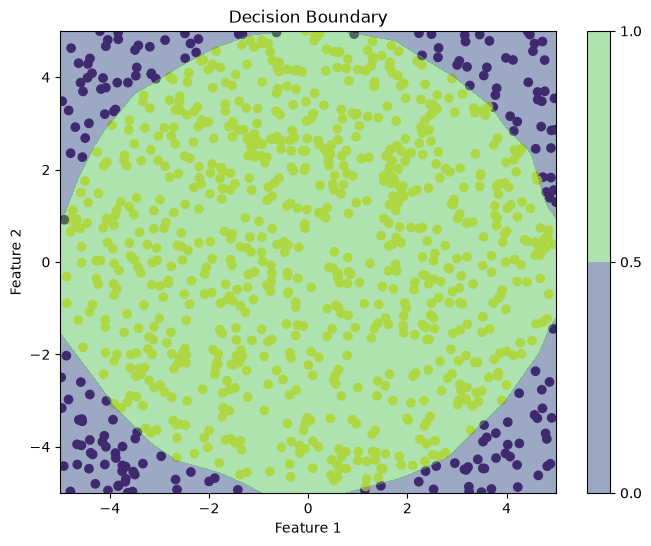

In [6]:
# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")

x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)

with torch.no_grad():
    Z = model(torch.tensor(np.column_stack((X1.ravel(), X2.ravel())), dtype=torch.float32))
    Z = Z.reshape(X1.shape)

plt.contourf(X1, X2, Z, levels=[0, 0.5, 1], cmap="viridis", alpha=0.5)
plt.colorbar()
plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [7]:
# Save the trained model
torch.save(model.state_dict(), "model.pth")

## 4. Creates a new instance of the model and evaluate 

In [8]:
# creates a new instance of the ANN class
model2 = ANN()

In [9]:
# loads the pre-trained model weights from the file 'model.pth' and assigns them to the model2 instance.
# set the model to evaluation mode. PyTorch, models have two modes: training mode and evaluation mode. Training mode is used during the training process, while evaluation mode is used for making predictions.

model2.load_state_dict(torch.load("model.pth"))
model2.eval()

ANN(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [10]:
# Prepare the input data for evaluation
X_test = np.random.rand(1, 2) * 10 - 5  # Generate a random test sample
X_tensor = torch.tensor(X_test, dtype=torch.float32)

In [11]:
# Run the model inference
with torch.no_grad():
    output = model2(X_tensor)
    y_pred = (output > 0.5).float().item()

print(f"Input: {X_test}")
print(f"Predicted output: {y_pred}")

Input: [[-1.19829199 -0.34973984]]
Predicted output: 1.0


# 5. Create the model artifact

In [12]:
!tar -czf model.tar.gz model.pth code/inference.py

# 6. Deploy the model as a SageMaker Endpoint

In [13]:
# v3 deploys a custom (bring-your-own script) model using sagemaker-core resource classes.
# There is no framework-specific PyTorchModel class in v3; instead we retrieve the framework
# inference image with image_uris and describe the container explicitly.
from sagemaker.core import image_uris
from sagemaker.core.resources import Model, EndpointConfig, Endpoint
from sagemaker.core.shapes.shapes import ContainerDefinition, ProductionVariant

[07/13/26 12:01:56] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=453824;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=453825;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

In [14]:
# Get the default SageMaker bucket
default_bucket = sagemaker_session.default_bucket()
print(f"The default SageMaker bucket is: {default_bucket}")

s3 = boto3.resource("s3")

key = "demo-model/model.tar.gz"

# Upload the model artifact to Amazon S3
s3.Bucket(default_bucket).upload_file("model.tar.gz", key)

model_data = f"s3://{default_bucket}/{key}"

role = "arn:aws:iam::729646638167:role/SageMakerRole"  # [execution-copy] explicit SageMaker execution role

The default SageMaker bucket is: sagemaker-us-west-1-729646638167


[07/13/26 12:01:57] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=453830;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=453831;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

In [15]:
# Deploy the custom PyTorch model with sagemaker-core resource classes.
# 1) Retrieve the managed PyTorch inference container image for this region.
# 2) Create a Model whose primary container points at the model artifact and inference.py.
# 3) Create an EndpointConfig + Endpoint from that model.
unique_id = str(uuid.uuid4())[:8]
model_name = f"custom-pytorch-model-{unique_id}"
endpoint_name = f"custom-pytorch-endpoint-{unique_id}"

inference_image_uri = image_uris.retrieve(
    framework="pytorch",
    region=region,
    version="2.3.0",
    py_version="py311",
    instance_type="ml.m5.xlarge",
    image_scope="inference",
)

Model.create(
    model_name=model_name,
    primary_container=ContainerDefinition(
        image=inference_image_uri,
        model_data_url=model_data,
        environment={
            "SAGEMAKER_PROGRAM": "inference.py",
            "SAGEMAKER_SUBMIT_DIRECTORY": model_data,
        },
    ),
    execution_role_arn=role,
    region=region,
)

EndpointConfig.create(
    endpoint_config_name=endpoint_name,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=model_name,
            initial_instance_count=1,
            instance_type="ml.m5.xlarge",
            initial_variant_weight=1.0,
        )
    ],
    region=region,
)

endpoint = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=endpoint_name,
    region=region,
)
endpoint.wait_for_status("InService")

# Get the endpoint name
endpoint_name = endpoint.endpoint_name

print(f"The deployed endpoint name is: {endpoint_name}")

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Creating model resource.                                            ]8;id=453838;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=453839;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=453846;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=453847;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=453852;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=453853;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

...

[07/13/26 12:01:58] INFO     Creating endpoint_config resource.                                  ]8;id=453865;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=453866;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=453872;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=453873;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 12:05:12] INFO     Final Resource Status: InService                                    ]8;id=453879;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=453880;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

The deployed endpoint name is: custom-pytorch-endpoint-7f634a2a


# 7. Performing inference using the SageMaker endpoint

In [16]:
# Define the endpoint name
endpoint_name = endpoint_name


# Define a function to preprocess the input data
def preprocess_input(X):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    return X_tensor


# Define a function to postprocess the model output
def postprocess_output(output):
    y_pred = (output > 0.5).float()
    return y_pred.item()


# Prepare the input data
X_test = np.random.rand(1, 2) * 10 - 5  # Generate a random test sample

# Preprocess the input data
X_tensor = preprocess_input(X_test)

# Convert the input data to JSON
input_data = {"features": X_tensor.tolist()}
payload = json.dumps(input_data)

# Invoke the SageMaker endpoint with the v3 core Endpoint resource
response = endpoint.invoke(body=payload, content_type="application/json")

# Postprocess the model output
result = json.loads(response.body.read().decode())
output = postprocess_output(torch.tensor(result["output"]))

print(f"Input: {X_test}")
print(f"Predicted output: {output}")

Input: [[-4.04606343 -4.3523935 ]]
Predicted output: 0.0


In [17]:
# delete the endpoint (and its endpoint config + model) using v3 core resources


def del_endpoint(ep_name):
    try:
        ep = Endpoint.get(endpoint_name=ep_name, region=region)
        print(f"Endpoint '{ep_name}' still exists. Deleting.....")
        try:
            EndpointConfig.get(endpoint_config_name=ep_name, region=region).delete()
        except Exception:
            pass
        ep.delete()
        print(f"Endpoint '{ep_name}' has been deleted.")
    except Exception as e:
        print(f"Endpoint '{ep_name}' could not be described (likely already deleted): {e}")


del_endpoint(endpoint_name)

# Clean up the standalone model resource created above
try:
    Model.get(model_name=model_name, region=region).delete()
    print(f"Model '{model_name}' has been deleted.")
except Exception as e:
    print(f"Model '{model_name}' could not be deleted: {e}")

Endpoint 'custom-pytorch-endpoint-7f634a2a' still exists. Deleting.....


                    INFO     Deleting EndpointConfig - custom-pytorch-endpoint-7f634a2a          ]8;id=458412;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458413;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

                    INFO     Deleting Endpoint - custom-pytorch-endpoint-7f634a2a                ]8;id=458419;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458420;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

Endpoint 'custom-pytorch-endpoint-7f634a2a' has been deleted.


[07/13/26 12:05:14] INFO     Deleting Model - custom-pytorch-model-7f634a2a                      ]8;id=458426;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458427;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

Model 'custom-pytorch-model-7f634a2a' has been deleted.


# 8. Let's import the custom model into the SageMaker Jumpstart private model hub

In [18]:
# v3: the JumpStart private hub is managed through sagemaker-core.
from sagemaker.core.jumpstart.hub.hub import Hub

In [19]:
# Grab the info we need for the hub content document.
model_data = f"s3://{default_bucket}/{key}"

from sagemaker.core import image_uris

image_uri = image_uris.retrieve(
    framework="pytorch",
    region=region,
    version="2.3.0",
    py_version="py311",
    image_scope="inference",
    instance_type="ml.c5.xlarge",
)
image_uri

'763104351884.dkr.ecr.us-west-1.amazonaws.com/pytorch-inference:2.3.0-cpu-py311'

In [20]:
default_bucket = sagemaker_session.default_bucket()
print(default_bucket)

sagemaker-us-west-1-729646638167


In [21]:
# Define the private model hub details. Names are suffixed with a unique id so the
# notebook can be re-run without ResourceInUse collisions.
HUB_NAME = f"Custom-Model-Hub-{unique_id}"
HUB_DISPLAY_NAME = HUB_NAME

REGION = region

# The SageMaker control-plane client used for hub creation and content import.
sm_client = boto3.client("sagemaker", region_name=region)
print(sagemaker_session.get_caller_identity_arn())

arn:aws:iam::729646638167:role/Admin


In [22]:
# Create the private model hub.
# NOTE: sagemaker-core's Hub.create()/describe() rely on Session.create_hub/describe_hub, which are
# not exposed on the core Session yet, so we use the native boto3 SageMaker CreateHub API directly.
# The boto3 CreateHub/DescribeHub calls are the same control-plane APIs the SDK wraps.
try:
    sm_client.create_hub(
        HubName=HUB_NAME,
        HubDescription=(
            "This is a Curated Hub. Replace this with a description which explains "
            "the purpose of this Hub."
        ),
        HubDisplayName=HUB_DISPLAY_NAME,
        S3StorageConfig={"S3OutputPath": f"s3://{default_bucket}/{HUB_NAME}"},
    )
    print(f"Successfully created Hub with name {HUB_NAME} in {REGION}")
except Exception as e:
    if "ResourceInUse" in str(e):
        print(f"A hub with the name {HUB_NAME} already exists in your account.")
    else:
        raise e

# Instantiate the core Hub object for subsequent list/describe operations.
hub = Hub(hub_name=HUB_NAME, sagemaker_session=sagemaker_session, bucket_name=default_bucket)

Successfully created Hub with name Custom-Model-Hub-7f634a2a in us-west-1


In [23]:
# below is a metadata dict for the models in Jumpstart. this information is used while training or hosting the models by Jumpstart.
# you might need to tweek based on the model that you are importing

hub_model_dict = {
    "Url": "https://anyuniversity.edu",
    "MinSdkVersion": "2.189.0",
    "TrainingSupported": False,
    "IncrementalTrainingSupported": False,
    "HostingArtifactUri": model_data,
    "HostingScriptUri": model_data,
    "HostingUseScriptUri": False,
    "InferenceDependencies": [],
    "InferenceEnvironmentVariables": [
        {
            "Name": "SAGEMAKER_PROGRAM",
            "Type": "text",
            "Default": "inference.py",
            "Scope": "container",
            "RequiredForModelClass": True,
        },
        {
            "Name": "SAGEMAKER_SUBMIT_DIRECTORY",
            "Type": "text",
            "Default": model_data,
            "Scope": "container",
            "RequiredForModelClass": False,
        },
        {
            "Name": "TS_MAX_RESPONSE_SIZE",
            "Type": "text",
            "Default": "100000000",
            "Scope": "container",
            "RequiredForModelClass": True,
        },
        {
            "Name": "TS_MAX_REQUEST_SIZE",
            "Type": "text",
            "Default": "100000000",
            "Scope": "container",
            "RequiredForModelClass": True,
        },
    ],
    "DefaultInferenceInstanceType": "ml.c5.4xlarge",
    "SupportedInferenceInstanceTypes": ["ml.c5.4xlarge", "ml.c5.9xlarge", "ml.g4dn.2xlarge"],
    "InferenceEnableNetworkIsolation": False,
    "ValidationSupported": False,
    "ResourceNameBase": "Custom-Model-Hub1",
    "HostingInstanceTypeVariants": {
        "Variants": {
            "c5": {"Properties": {"ImageUri": image_uri}},
            "ml.c5.4xlarge": {"Properties": {"ResourceRequirements": {"MinMemoryMb": 16384}}},
            "ml.c5.9xlarge": {"Properties": {"ResourceRequirements": {"MinMemoryMb": 32768}}},
        }
    },
    "HostingArtifactS3DataType": "S3Prefix",
    "HostingArtifactCompressionType": "Gzip",
    "HostingResourceRequirements": {"MinMemoryMb": 16384},
    "DynamicContainerDeploymentSupported": True,
    "Dependencies": [],
    "HostingEcrUri": image_uri,
    "Task": "blog model",
    "Framework": "custom",
    "SageMakerSdkPredictorSpecifications": {
        "SupportedContentTypes": ["application/x-image"],
        "SupportedAcceptTypes": [
            "application/json",
            "application/json;verbose",
            "application/json;n_predictions=2",
        ],
        "DefaultContentType": "application/x-image",
        "DefaultAcceptType": "application/json",
    },
}

# Convert the dictionary to a JSON string
hub_doc = json.dumps(hub_model_dict)

# If you need to parse it back into a dictionary (which you shouldn't need to do in this case)
# hub_model_dict = json.loads(hub_doc)

print(hub_doc)

{"Url": "https://anyuniversity.edu", "MinSdkVersion": "2.189.0", "TrainingSupported": false, "IncrementalTrainingSupported": false, "HostingArtifactUri": "s3://sagemaker-us-west-1-729646638167/demo-model/model.tar.gz", "HostingScriptUri": "s3://sagemaker-us-west-1-729646638167/demo-model/model.tar.gz", "HostingUseScriptUri": false, "InferenceDependencies": [], "InferenceEnvironmentVariables": [{"Name": "SAGEMAKER_PROGRAM", "Type": "text", "Default": "inference.py", "Scope": "container", "RequiredForModelClass": true}, {"Name": "SAGEMAKER_SUBMIT_DIRECTORY", "Type": "text", "Default": "s3://sagemaker-us-west-1-729646638167/demo-model/model.tar.gz", "Scope": "container", "RequiredForModelClass": false}, {"Name": "TS_MAX_RESPONSE_SIZE", "Type": "text", "Default": "100000000", "Scope": "container", "RequiredForModelClass": true}, {"Name": "TS_MAX_REQUEST_SIZE", "Type": "text", "Default": "100000000", "Scope": "container", "RequiredForModelClass": true}], "DefaultInferenceInstanceType": "ml.

In [24]:
# importing to the hub

sm_client.import_hub_content(
    HubContentName="blog-model-test0213",
    HubContentType="Model",
    DocumentSchemaVersion="2.2.0",
    HubName=HUB_NAME,
    HubContentDocument=hub_doc,
)

{'HubArn': 'arn:aws:sagemaker:us-west-1:729646638167:hub/Custom-Model-Hub-7f634a2a',
 'HubContentArn': 'arn:aws:sagemaker:us-west-1:729646638167:hub-content/Custom-Model-Hub-7f634a2a/Model/blog-model-test0213/0.0.1',
 'ResponseMetadata': {'RequestId': '7806c9c3-a9ca-44f8-bad7-541bf0d861de',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '7806c9c3-a9ca-44f8-bad7-541bf0d861de',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '212',
   'date': 'Mon, 13 Jul 2026 19:05:15 GMT'},
  'RetryAttempts': 0}}

In [25]:
# list the models from the private hub
hub.list_models()

{'hub_content_summaries': [{'HubContentName': 'blog-model-test0213',
   'HubContentArn': 'arn:aws:sagemaker:us-west-1:729646638167:hub-content/Custom-Model-Hub-7f634a2a/Model/blog-model-test0213/0.0.1',
   'HubContentVersion': '0.0.1',
   'HubContentType': 'Model',
   'DocumentSchemaVersion': '2.2.0',
   'HubContentStatus': 'Available',
   'CreationTime': datetime.datetime(2026, 7, 13, 12, 5, 14, 948000, tzinfo=tzlocal()),
   'OriginalCreationTime': datetime.datetime(2026, 7, 13, 12, 5, 14, 948000, tzinfo=tzlocal())}],
 'next_token': None}

In [26]:
# retrieve the HUB's arn via the native DescribeHub API
HUB_ARN = sm_client.describe_hub(HubName=HUB_NAME)["HubArn"]
print(HUB_ARN)

# get the model id
model_id = hub.list_models()["hub_content_summaries"][0]["HubContentName"]
print(model_id)

# get the model version
version = hub.list_models()["hub_content_summaries"][0]["HubContentVersion"]
print(version)

arn:aws:sagemaker:us-west-1:729646638167:hub/Custom-Model-Hub-7f634a2a
blog-model-test0213
0.0.1


# 9. Deploy the model from private model hub as a real time inference endpoint

In [27]:
# Deploy the model straight from the private model hub.
#
# NOTE ON THE V3 PATH: the high-level ModelBuilder.from_jumpstart_config() JumpStart path does not
# yet support *custom* content imported into a private hub -- ModelBuilder._is_jumpstart_model_id()
# only checks the public JumpStart catalog and ignores the hub ARN, so a private custom model is
# mis-routed to the HuggingFace path. Until that is supported, we read the model definition back
# from the private hub with DescribeHubContent and deploy it with the sagemaker-core resource
# classes (same primitives used earlier in this notebook).
hub_content = sm_client.describe_hub_content(
    HubName=HUB_NAME,
    HubContentType="Model",
    HubContentName=model_id,
    HubContentVersion=version,
)
hub_doc = json.loads(hub_content["HubContentDocument"])

# Pull the container image, model artifact, and inference env out of the hub content document.
hub_image_uri = hub_doc["HostingEcrUri"]
hub_model_data = hub_doc["HostingArtifactUri"]
hub_env = {
    v["Name"]: v["Default"]
    for v in hub_doc.get("InferenceEnvironmentVariables", [])
    if "Default" in v
}
hub_instance_type = hub_doc.get("DefaultInferenceInstanceType", "ml.c5.4xlarge")

unique_id2 = str(uuid.uuid4())[:8]
hub_model_name = f"hub-model-{unique_id2}"
endpoint_name = f"hub-endpoint-{unique_id2}"

core_model = Model.create(
    model_name=hub_model_name,
    primary_container=ContainerDefinition(
        image=hub_image_uri,
        model_data_url=hub_model_data,
        environment=hub_env,
    ),
    execution_role_arn=role,
    region=region,
)

EndpointConfig.create(
    endpoint_config_name=endpoint_name,
    production_variants=[
        ProductionVariant(
            variant_name="AllTraffic",
            model_name=hub_model_name,
            initial_instance_count=1,
            instance_type=hub_instance_type,
            initial_variant_weight=1.0,
        )
    ],
    region=region,
)

hub_endpoint = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=endpoint_name,
    region=region,
)
hub_endpoint.wait_for_status("InService")

endpoint_name = hub_endpoint.endpoint_name
endpoint_name

[07/13/26 12:05:15] INFO     Creating model resource.                                            ]8;id=458432;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458433;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20477\20477]8;;\

[07/13/26 12:05:16] INFO     Creating endpoint_config resource.                                  ]8;id=458438;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458439;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=458444;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458445;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/13/26 12:08:09] INFO     Final Resource Status: InService                                    ]8;id=458450;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=458451;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

'hub-endpoint-341d43d3'

# 10. Lets invoke the newly deployed endpoint

In [28]:
# Prepare the input data
X_test = np.random.rand(1, 2) * 10 - 5  # Generate a random test sample

# Preprocess the input data
X_tensor = preprocess_input(X_test)

# Convert the input data to JSON
input_data = {"features": X_tensor.tolist()}
payload = json.dumps(input_data)

# Invoke the SageMaker endpoint with the v3 core Endpoint resource
response = hub_endpoint.invoke(body=payload, content_type="application/json")

# Postprocess the model output
result = json.loads(response.body.read().decode())
output = postprocess_output(torch.tensor(result["output"]))

print(f"Input: {X_test}")
print(f"Predicted output: {output}")

Input: [[-4.16625201  3.07944273]]
Predicted output: 0.0


# 11. Clean up

In [29]:
# Clean up the endpoint deployed from the private hub, plus its config and model.
del_endpoint(endpoint_name)

try:
    core_model.delete()
    print(f"Model '{core_model.model_name}' has been deleted.")
except Exception as e:
    print(f"Hub-deployed model could not be deleted: {e}")

Endpoint 'hub-endpoint-341d43d3' still exists. Deleting.....


                    INFO     Deleting EndpointConfig - hub-endpoint-341d43d3                     ]8;id=462512;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=462513;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

                    INFO     Deleting Endpoint - hub-endpoint-341d43d3                           ]8;id=462518;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=462519;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

Endpoint 'hub-endpoint-341d43d3' has been deleted.


                    INFO     Deleting Model - hub-model-341d43d3                                 ]8;id=462524;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=462525;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20624\20624]8;;\

Model 'hub-model-341d43d3' has been deleted.


## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.


![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/NOTEBOOK_PATH)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/NOTEBOOK_PATH)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/NOTEBOOK_PATH)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/NOTEBOOK_PATH)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/NOTEBOOK_PATH)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/NOTEBOOK_PATH)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/NOTEBOOK_PATH)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/NOTEBOOK_PATH)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/NOTEBOOK_PATH)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/NOTEBOOK_PATH)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/NOTEBOOK_PATH)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/NOTEBOOK_PATH)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/NOTEBOOK_PATH)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/NOTEBOOK_PATH)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/NOTEBOOK_PATH)
